<a href="https://colab.research.google.com/github/ahmedinB/Extrapolation/blob/main/Extrapolation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import torch
import matplotlib.pyplot as plt

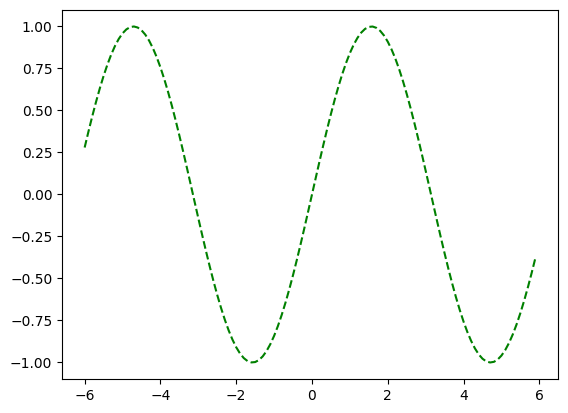

In [2]:
x = torch.arange(-6, 6, .1)
y = torch.sin(x)
plt.plot(x, y, 'g--')

In [3]:
trainx = x[(x >= -3) & (x <= 3)]
trainy = torch.sin(trainx) + torch.normal(0, 0.1, trainx.shape)

In [4]:
# @title
class MLP(torch.nn.Module):
  def __init__(self):
    super().__init__()

    self.subnet1 = torch.nn.Linear(1, 16)
    self.subnet2 = torch.nn.Linear(16, 16)
    self.subnet3 = torch.nn.Linear(16, 1)

  def forward(self, x):
    x = torch.nn.functional.sigmoid(self.subnet1(x))
    x = torch.nn.functional.sigmoid(self.subnet2(x))
    x = self.subnet3(x)

    return x



In [5]:
# @title
class SubNet(torch.nn.Module):
    def __init__(self, depth=3, width=16):
        super().__init__()
        # Creating a list of layers based on depth
        layers = []
        in_dim = 1
        for _ in range(depth):
            layers.append(torch.nn.Linear(in_dim, width))
            layers.append(torch.nn.Sigmoid())
            in_dim = width
        self.features = torch.nn.Sequential(*layers)
        self.output = torch.nn.Linear(width, 1)

    def forward(self, x):
        return self.output(self.features(x))

class ProposedNet(torch.nn.Module):
    def __init__(self):
        super().__init__()
        # Three subnets of varying length (1, 2, and 3 layers)
        self.path1 = SubNet(depth=1)
        self.path2 = SubNet(depth=2)
        self.path3 = SubNet(depth=3)

        # Learnable weights for the combination
        self.alpha = torch.nn.Parameter(torch.ones(3) / 3)

    def forward(self, x):
        # Linear combination as described in the paper
        return (self.alpha[0] * self.path1(x) +
                self.alpha[1] * self.path2(x) +
                self.alpha[2] * self.path3(x))


# Doesnt work as it does not ensure structural variablity because the weights are not shared to mix different losses gradients

In [6]:
# @title
import torch
import torch.nn as nn
from typing import Sequence, Tuple


def make_activation(name: str) -> nn.Module:
    name = name.lower()
    if name == "sigmoid":
        return nn.Sigmoid()
    if name == "tanh":
        return nn.Tanh()
    raise ValueError(f"Unsupported activation: {name}. Use 'sigmoid' or 'tanh'.")


class StandardMLP(nn.Module):
    """
    Baseline 3-hidden-layer MLP.
    """
    def __init__(
        self,
        in_dim: int,
        out_dim: int = 1,
        hidden_dim: int = 16,
        depth: int = 3,
        activation: str = "sigmoid",
    ) -> None:
        super().__init__()
        if depth < 1:
            raise ValueError("depth must be >= 1")

        self.act = make_activation(activation)
        self.hidden_layers = nn.ModuleList()

        prev_dim = in_dim
        for _ in range(depth):
            self.hidden_layers.append(nn.Linear(prev_dim, hidden_dim))
            prev_dim = hidden_dim

        self.out = nn.Linear(hidden_dim, out_dim)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        h = x
        for layer in self.hidden_layers:
            h = self.act(layer(h))
        return self.out(h)


class VariableDepthExtrapolationMLP(nn.Module):
    """
    Proposed model:
    linearly combine predictions from subnetworks of different depths.

    If depths=(1, 2, 3), then the model computes:
        y = a1 * head1(h1) + a2 * head2(h2) + a3 * head3(h3)

    where:
        h1 = act(W1 x + b1)
        h2 = act(W2 h1 + b2)
        h3 = act(W3 h2 + b3)
    """
    def __init__(
        self,
        in_dim: int,
        out_dim: int = 1,
        hidden_dim: int = 16,
        max_depth: int = 3,
        depths: Sequence[int] = (1, 2, 3),
        activation: str = "sigmoid",
        normalize_mixing: bool = False,
    ) -> None:
        super().__init__()

        depths = tuple(sorted(set(int(d) for d in depths)))

        self.depths: Tuple[int, ...] = depths
        self.normalize_mixing = normalize_mixing
        self.act = make_activation(activation)

        # Shared backbone up to max_depth.
        self.hidden_layers = nn.ModuleList()
        prev_dim = in_dim
        for _ in range(max_depth):
            self.hidden_layers.append(nn.Linear(prev_dim, hidden_dim))
            prev_dim = hidden_dim

        # One readout head for each chosen depth.
        self.heads = nn.ModuleDict({
            str(d): nn.Linear(hidden_dim, out_dim) for d in self.depths
        })

        # Learnable linear-combination weights.
        self.mix = nn.Parameter(torch.ones(len(self.depths)) / len(self.depths))

    def forward(self, x: torch.Tensor, return_branches: bool = False):
        h = x
        branch_outputs = []

        for depth, layer in enumerate(self.hidden_layers, start=1):
            h = self.act(layer(h))
            key = str(depth)
            if key in self.heads:
                branch_outputs.append(self.heads[key](h))

        # [num_branches, batch, out_dim]
        branch_outputs = torch.stack(branch_outputs, dim=0)

        if self.normalize_mixing:
            weights = torch.softmax(self.mix, dim=0)
        else:
            weights = self.mix  # literal linear combination

        y = (weights.view(-1, 1, 1) * branch_outputs).sum(dim=0)

        if return_branches:
            branch_dict = {
                depth: branch_outputs[i] for i, depth in enumerate(self.depths)
            }
            return y, branch_dict, weights

        return y

In [14]:
standardMLP, proposal = StandardMLP(in_dim = 1), VariableDepthExtrapolationMLP(in_dim = 1)
optimizer1 = torch.optim.Adam(standardMLP.parameters(), lr = 1e-2)
optimizer2 = torch.optim.Adam(proposal.parameters(), lr = 1e-2)

In [15]:
# @title
def plot(model1, model2):
  with torch.no_grad():
          fig, ax = plt.subplots(1, 2, figsize = (10, 4))
          ax[0].plot(x, model1(x.unsqueeze(1)), "--", label = 'Prediction')
          ax[0].plot(x, y)
          ax[0].scatter(trainx, trainy, s = 5, color = 'green', label = 'Training Data')
          ax[0].legend()
          ax[0].set_title("Standard (MLP)")
          ax[0].grid(True)
          ax[1].plot(x, model2(x.unsqueeze(1)), "--", label = 'Prediction')
          ax[1].plot(x, y)
          ax[1].scatter(trainx, trainy, s = 5, color = 'green', label = 'Training Data')
          ax[1].legend()
          ax[1].set_title('Proposal')
          ax[1].grid(True)
          plt.show()

In [16]:
# @title
def train(m, opt, l_fn):
  loss_memory = float('inf')
  upturn, patience = 0, 50
  for e in range(100000+1):
    opt.zero_grad()
    mloss = l_fn(m(trainx.unsqueeze(1)).squeeze(), trainy)

    # Early Stop
    mlossX = l_fn(m(x.unsqueeze(1)).squeeze(), y)

    if loss_memory < mlossX.item():
      upturn += 1
      if upturn == patience:
        print('Model Early Stopped')
        print(50*'+')

        return m
    else:
      upturn = 0
    print(e, mlossX.item(), upturn)
    loss_memory = mlossX.item()
    mloss.backward()
    opt.step()

In [17]:
standardMLP.train()
proposal.train()
loss_fn = torch.nn.MSELoss()
standardMLP = train(standardMLP, optimizer1, loss_fn)
proposal = train(proposal, optimizer2, loss_fn)


0 0.5339952111244202 0
1 0.5256693959236145 0
2 0.5355059504508972 1
3 0.5355745553970337 2
4 0.531691312789917 0
5 0.5312640070915222 0
6 0.5350520610809326 1
7 0.5392876863479614 2
8 0.5418292880058289 3
9 0.5438859462738037 4
10 0.5474408268928528 5
11 0.5532222986221313 6
12 0.5605924129486084 7
13 0.5688397884368896 8
14 0.5782166719436646 9
15 0.5898248553276062 10
16 0.604913055896759 11
17 0.6243183016777039 12
18 0.6483858823776245 13
19 0.6773054003715515 14
20 0.711544930934906 15
21 0.7520860433578491 16
22 0.8003794550895691 17
23 0.8581115007400513 18
24 0.9269049167633057 19
25 1.0080225467681885 20
26 1.1020411252975464 21
27 1.2083745002746582 22
28 1.324501633644104 23
29 1.4450087547302246 24
30 1.5613361597061157 25
31 1.6634290218353271 26
32 1.7426201105117798 27
33 1.7936161756515503 28
34 1.814995527267456 29
35 1.8086637258529663 0
36 1.7787423133850098 0
37 1.7304670810699463 0
38 1.6694004535675049 0
39 1.6009256839752197 0
40 1.5299018621444702 0
41 1.460417

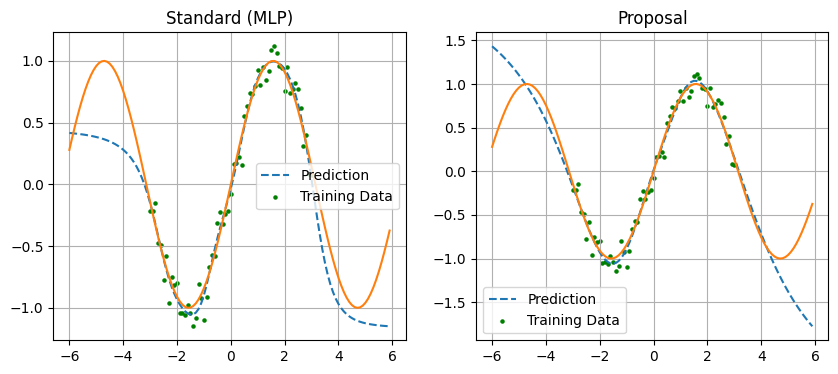

In [18]:
plot(standardMLP, proposal)